# Parte 1 - Iteración 6: Ataque Final al Leaderboard con Caracteres Puros

Esta iteración está diseñada para intentar construir el mejor modelo posible dentro de las reglas de la Parte 1.

Contexto actual:
- Mejor score propio observado en Kaggle: `0.28653`
- Referencia del leaderboard: `0.30372`
- Mejor familia de modelos encontrada hasta ahora: `TF-IDF` de caracteres puros + `LinearSVC`

Objetivo de esta versión:
- maximizar el rendimiento del pipeline clásico,
- concentrar el esfuerzo únicamente en el enfoque que realmente ha funcionado,
- intentar acercarse al líder del tablero sin salir de los límites del enunciado.

Principio metodológico:
- no se exploran más modelos de palabras ni uniones que ya mostraron ser inferiores,
- solo se ajustan variantes del mejor modelo: caracteres puros,
- se busca mejorar mediante rango de n-gramas, `max_features` y `C`.

Legalidad:
- solo usa `scikit-learn`,
- no usa deep learning,
- no usa transformers,
- no usa embeddings neuronales,
- no usa `eval.csv` para entrenar ni ajustar.

Artefactos que generará esta iteración:
- `best_model_v6.joblib`
- `submission_v6.csv`


In [1]:
import os
import time
import warnings
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str((Path.cwd() / ".mplconfig").resolve())
warnings.filterwarnings("ignore")

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
TRAIN_PATH = DATA_DIR / "train.csv"
EVAL_PATH = DATA_DIR / "eval.csv"
MODEL_PATH = BASE_DIR / "best_model_v6.joblib"
SUBMISSION_PATH = BASE_DIR / "submission_v6.csv"

print(f"Directorio base: {BASE_DIR}")
print(f"Train path: {TRAIN_PATH}")
print(f"Eval path: {EVAL_PATH}")
print(f"Modelo de salida: {MODEL_PATH.name}")
print(f"Submission de salida: {SUBMISSION_PATH.name}")


Directorio base: /Users/mattia/Desktop/ProyectoML
Train path: /Users/mattia/Desktop/ProyectoML/data/train.csv
Eval path: /Users/mattia/Desktop/ProyectoML/data/eval.csv
Modelo de salida: best_model_v6.joblib
Submission de salida: submission_v6.csv


## 1. Carga de datos

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
eval_df = pd.read_csv(EVAL_PATH)

train_df["text"] = train_df["text"].fillna("")
eval_df["text"] = eval_df["text"].fillna("")
train_df["decade"] = train_df["decade"].astype(int)

assert list(train_df.columns) == ["text", "decade"]
assert list(eval_df.columns) == ["id", "text"]

print("Shape train:", train_df.shape)
print("Shape eval:", eval_df.shape)

train_df.head()


Shape train: (31403, 2)
Shape eval: (3490, 2)


,text,decade
0,"\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \nnes parece que aísilte, O ayuda Calsiodoro \nl...",164
1,"gone. Sus amigos , sus clientes, todo \ncuanto le rodea le prueban que es hom- \nbre de mucha importancia. Si ve que al- \ngunos hombre» plebeyos á fuerza de ser- \nvicios y de...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan feratormentados, e \nante quien,e quie preguntasles deuan hazer mientras los tormentarf, \nvecla.lstitopuzo",157
3,"Caistro el M a y o r a i .] Del apellido de Cañroíe \nvalió Don Luis enefta. Metáfora, para el nombre que fupo \nne de Caiftro. Mayoral fe llama entr...",163
4,"\nlos que panden macho ; y \notros en la fu ña abundan¬ \ncia , íiempre viuen como \nmendigos. La Lana aun en \nel edito fagrado compite \ncon el Sol lu...",166


## 2. Motivación de la iteración 6

Hallazgos de las iteraciones previas:
- el mejor modelo dejó de ser `char_wb` y pasó a ser `char` puro,
- la mezcla palabra + carácter no consiguió superar al mejor modelo puramente de caracteres,
- por lo tanto, la mejor estrategia ahora es profundizar únicamente en el espacio de caracteres puros.

Se probarán tres palancas:
- `ngram_range`
- `max_features`
- `C`


In [3]:
train_df["text_len_chars"] = train_df["text"].str.len()
train_df["text_len_words"] = train_df["text"].str.split().str.len()

summary_df = pd.DataFrame(
    {
        "metric": [
            "n_filas_train",
            "n_filas_eval",
            "n_clases",
            "promedio_chars",
            "mediana_chars",
            "promedio_words",
            "mediana_words",
        ],
        "valor": [
            len(train_df),
            len(eval_df),
            train_df["decade"].nunique(),
            float(train_df["text_len_chars"].mean()),
            float(train_df["text_len_chars"].median()),
            float(train_df["text_len_words"].mean()),
            float(train_df["text_len_words"].median()),
        ],
    }
)

summary_df


,metric,valor
0,n_filas_train,31403.00000
1,n_filas_eval,3490.00000
2,n_clases,39.00000
3,promedio_chars,520.56829
4,mediana_chars,315.00000
5,promedio_words,82.28319
6,mediana_words,50.00000


## 3. División de validación

Se conserva la división estratificada `80/20` para mantener comparabilidad con las iteraciones anteriores.

In [4]:
X = train_df["text"]
y = train_df["decade"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Shape X_train:", X_train.shape)
print("Shape X_valid:", X_valid.shape)


Shape X_train: (25122,)
Shape X_valid: (6281,)


## 4. Modelos candidatos para el ataque final

Se construyen solo variantes de caracteres puros. Se incluyen:
- referencias cercanas al mejor modelo actual,
- variantes con n-gramas más amplios,
- variantes con más características,
- ajustes finos de `C`.

Esta es la búsqueda más agresiva realizada hasta ahora, por lo que puede tardar más.

In [5]:
def build_char_model(c_value=0.85, ngram_range=(3, 5), max_features=100000):
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    strip_accents="unicode",
                    analyzer="char",
                    ngram_range=ngram_range,
                    min_df=2,
                    sublinear_tf=True,
                    max_features=max_features,
                    dtype=np.float32,
                ),
            ),
            ("clf", LinearSVC(C=c_value)),
        ]
    )


candidate_models = {
    "char_ref_c085_3_5_100k": build_char_model(c_value=0.85, ngram_range=(3, 5), max_features=100000),
    "char_ref_c080_3_5_100k": build_char_model(c_value=0.80, ngram_range=(3, 5), max_features=100000),
    "char_ref_c095_3_5_100k": build_char_model(c_value=0.95, ngram_range=(3, 5), max_features=100000),
    "char_c085_2_5_120k": build_char_model(c_value=0.85, ngram_range=(2, 5), max_features=120000),
    "char_c080_2_5_120k": build_char_model(c_value=0.80, ngram_range=(2, 5), max_features=120000),
    "char_c090_2_5_120k": build_char_model(c_value=0.90, ngram_range=(2, 5), max_features=120000),
    "char_c085_2_6_150k": build_char_model(c_value=0.85, ngram_range=(2, 6), max_features=150000),
    "char_c080_2_6_150k": build_char_model(c_value=0.80, ngram_range=(2, 6), max_features=150000),
    "char_c095_2_6_150k": build_char_model(c_value=0.95, ngram_range=(2, 6), max_features=150000),
    "char_c085_3_6_150k": build_char_model(c_value=0.85, ngram_range=(3, 6), max_features=150000),
    "char_c075_2_6_180k": build_char_model(c_value=0.75, ngram_range=(2, 6), max_features=180000),
}

list(candidate_models.keys())


['char_ref_c085_3_5_100k',
 'char_ref_c080_3_5_100k',
 'char_ref_c095_3_5_100k',
 'char_c085_2_5_120k',
 'char_c080_2_5_120k',
 'char_c090_2_5_120k',
 'char_c085_2_6_150k',
 'char_c080_2_6_150k',
 'char_c095_2_6_150k',
 'char_c085_3_6_150k',
 'char_c075_2_6_180k']

In [6]:
def evaluate_models(models, X_train, y_train, X_valid, y_valid):
    rows = []
    fitted_models = {}

    for name, model in models.items():
        print(f"Entrenando {name}...")
        start = time.perf_counter()
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)
        valid_pred = fitted_model.predict(X_valid)
        elapsed = time.perf_counter() - start

        rows.append(
            {
                "model": name,
                "accuracy": accuracy_score(y_valid, valid_pred),
                "macro_f1": f1_score(y_valid, valid_pred, average="macro"),
                "train_seconds": round(elapsed, 2),
            }
        )
        fitted_models[name] = fitted_model

    results_df = pd.DataFrame(rows).sort_values(
        by=["accuracy", "macro_f1", "train_seconds"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    return results_df, fitted_models


results_df, fitted_models = evaluate_models(
    candidate_models,
    X_train,
    y_train,
    X_valid,
    y_valid,
)

results_df


Entrenando char_ref_c085_3_5_100k...
Entrenando char_ref_c080_3_5_100k...
Entrenando char_ref_c095_3_5_100k...
Entrenando char_c085_2_5_120k...
Entrenando char_c080_2_5_120k...
Entrenando char_c090_2_5_120k...
Entrenando char_c085_2_6_150k...
Entrenando char_c080_2_6_150k...
Entrenando char_c095_2_6_150k...
Entrenando char_c085_3_6_150k...
Entrenando char_c075_2_6_180k...


,model,accuracy,macro_f1,train_seconds
0,char_c075_2_6_180k,0.269543,0.262052,89.10
1,char_c080_2_5_120k,0.269384,0.262572,64.80
2,char_c090_2_5_120k,0.269225,0.262970,64.42
3,char_c085_2_5_120k,0.269225,0.262638,63.49
4,char_c080_2_6_150k,0.269225,0.262156,88.21
5,char_c085_2_6_150k,0.268269,0.261347,88.91
6,char_c095_2_6_150k,0.267951,0.261656,90.68
7,char_c085_3_6_150k,0.263971,0.257067,80.74
8,char_ref_c080_3_5_100k,0.261742,0.254406,53.93
9,char_ref_c085_3_5_100k,0.261583,0.254439,55.10


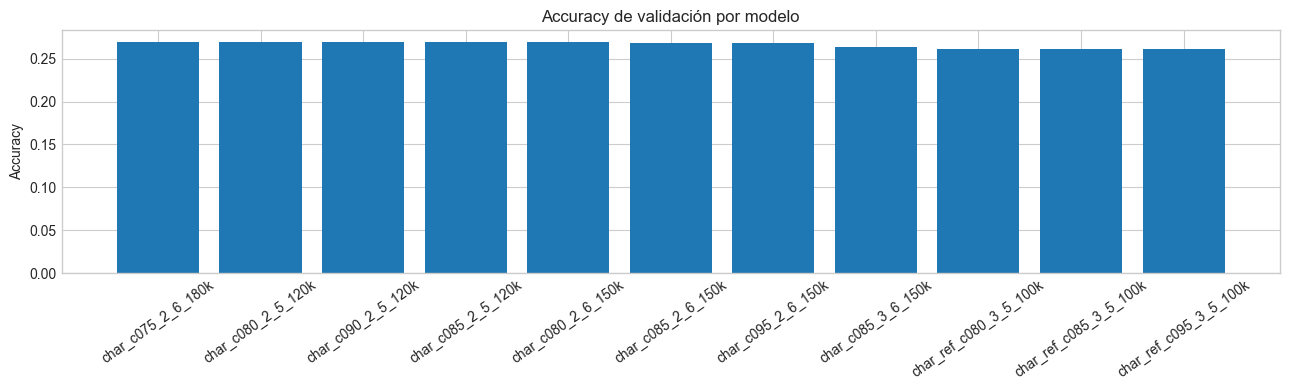

In [7]:
fig, ax = plt.subplots(figsize=(13, 4))
plot_df = results_df.sort_values("accuracy", ascending=False)
ax.bar(plot_df["model"], plot_df["accuracy"], color="#1f77b4")
ax.set_title("Accuracy de validación por modelo")
ax.set_ylabel("Accuracy")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


## 5. Selección del mejor modelo

El mejor pipeline se escoge automáticamente por `accuracy` de validación, seguido de `macro_f1` y luego tiempo de entrenamiento.

In [8]:
best_model_name = results_df.iloc[0]["model"]
best_valid_accuracy = results_df.iloc[0]["accuracy"]
best_valid_macro_f1 = results_df.iloc[0]["macro_f1"]
best_model = fitted_models[best_model_name]

print(f"Modelo final seleccionado: {best_model_name}")
print(f"Accuracy de validación: {best_valid_accuracy:.4f}")
print(f"Macro-F1 de validación: {best_valid_macro_f1:.4f}")


Modelo final seleccionado: char_c075_2_6_180k
Accuracy de validación: 0.2695
Macro-F1 de validación: 0.2621


## 6. Entrenamiento final con todos los datos y exportación

Una vez seleccionado el mejor pipeline, se reentrena usando todo `train.csv` y se generan los artefactos de la iteración 6.

In [9]:
final_model = clone(candidate_models[best_model_name])
final_model.fit(X, y)

joblib.dump(final_model, MODEL_PATH)

eval_predictions = final_model.predict(eval_df["text"]).astype(int)
submission_df = pd.DataFrame(
    {
        "id": eval_df["id"],
        "answer": eval_predictions,
    }
)
submission_df.to_csv(SUBMISSION_PATH, index=False)

print(f"Modelo guardado en: {MODEL_PATH}")
print(f"Submission guardado en: {SUBMISSION_PATH}")

submission_df.head()


Modelo guardado en: /Users/mattia/Desktop/ProyectoML/best_model_v6.joblib
Submission guardado en: /Users/mattia/Desktop/ProyectoML/submission_v6.csv


,id,answer
0,0,173
1,1,185
2,2,150
3,3,169
4,4,153


## 7. Resumen de la iteración 6

Interpretación esperada:
- si una variante con n-gramas más amplios gana, significa que el modelo todavía podía explotar mejor la estructura ortográfica del corpus,
- si gana una referencia cercana al mejor modelo previo, probablemente ya se está tocando el techo práctico del enfoque clásico usado.

Esta es la iteración más ambiciosa construida hasta ahora dentro de la Parte 1.

In [10]:
summary_lines = [
    f"Modelo final seleccionado: {best_model_name}",
    f"Accuracy de validación: {best_valid_accuracy:.4f}",
    f"Macro-F1 de validación: {best_valid_macro_f1:.4f}",
    f"Modelos evaluados: {', '.join(results_df['model'].tolist())}",
    "Motivo de la iteración: exprimir el mejor enfoque encontrado, concentrando la búsqueda en caracteres puros.",
    "Interpretación: esta versión prioriza al máximo el rendimiento dentro de modelos clásicos de scikit-learn.",
]

print("\n".join(summary_lines))


Modelo final seleccionado: char_c075_2_6_180k
Accuracy de validación: 0.2695
Macro-F1 de validación: 0.2621
Modelos evaluados: char_c075_2_6_180k, char_c080_2_5_120k, char_c090_2_5_120k, char_c085_2_5_120k, char_c080_2_6_150k, char_c085_2_6_150k, char_c095_2_6_150k, char_c085_3_6_150k, char_ref_c080_3_5_100k, char_ref_c085_3_5_100k, char_ref_c095_3_5_100k
Motivo de la iteración: exprimir el mejor enfoque encontrado, concentrando la búsqueda en caracteres puros.
Interpretación: esta versión prioriza al máximo el rendimiento dentro de modelos clásicos de scikit-learn.


## 8. Cómo ejecutar esta iteración

Esta búsqueda puede ser notablemente más lenta que las anteriores.

Ejecución interactiva:

```bash
cd /Users/mattia/Desktop/ProyectoML
source .venv/bin/activate
jupyter notebook parte1_iteracion6.ipynb
```

Ejecución sin interfaz:

```bash
cd /Users/mattia/Desktop/ProyectoML
source .venv/bin/activate
jupyter nbconvert --to notebook --execute --inplace parte1_iteracion6.ipynb
```
